# 02 · Segmentation candidate 2 — SAM

Fine-tunes SAM's mask decoder on Cuba's pixel ground truth with box prompts (encoder frozen, embeddings cached), and scores both the zero-shot and the fine-tuned model with the same benchmark used in 01 and 03.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

> **Needs first:** `00_setup_and_data.ipynb`

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [1]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49919771
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [2]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

### The shared segmentation scorer

Notebooks 01–03 each fine-tune a different segmenter; notebook 04 declares a winner. That
comparison is only meaningful if all three are scored by **the same code, on the same held-out
smears, at the same resolution, in the same automatic (no-ground-truth-prompt) mode**. That code is
this cell, and it is byte-identical in 01, 02 and 03.

* **Held-out smears with pixel ground truth only.** SAM-pseudo-labelled smears are excluded from
  scoring — grading SAM against SAM's own labels would be circular.
* **Instance-level, not pixel-level.** `F1@IoU0.5` is the headline: a cell counts as found only if
  one predicted mask overlaps it by ≥ 50 %. Pixel union-IoU is reported too, but a method can score
  well on it while merging every touching cell into one blob.
* **`mask AP@50` and `AP@50-95`** are COCO-style, single class, pooled over smears — comparable to
  the number Ultralytics prints for YOLO.
* **Seconds per smear** is recorded, because a segmenter that needs 40 s per slide is not a
  screening tool no matter what its F1 is.

In [3]:
# ═════════════════════════════════════════════════════════════════════════════
#  SHARED SEGMENTATION BENCHMARK -- byte-identical in notebooks 01, 02 and 03
# ═════════════════════════════════════════════════════════════════════════════
EVAL_SIDE = CFG['eval_side']


class Inst:
    '''one instance mask as (bbox, cropped bool array).

    200 cells x 3 MP as full-frame arrays is ~600 MB; this is ~2 MB.'''
    __slots__ = ('x0', 'y0', 'x1', 'y1', 'm', 'score', 'area')

    def __init__(self, mask, score=1.0):
        ys, xs = np.nonzero(mask)
        self.x0, self.x1 = int(xs.min()), int(xs.max()) + 1
        self.y0, self.y1 = int(ys.min()), int(ys.max()) + 1
        self.m = np.ascontiguousarray(mask[self.y0:self.y1, self.x0:self.x1])
        self.score = float(score)
        self.area = int(self.m.sum())


def to_insts(masks, scores=None):
    out = []
    for i, m in enumerate(masks):
        m = np.asarray(m, bool)
        if m.sum() < 12:                       # a 3x4 blob is not a cell
            continue
        out.append(Inst(m, 1.0 if scores is None else scores[i]))
    return out


def iou(a, b):
    x0, y0 = max(a.x0, b.x0), max(a.y0, b.y0)
    x1, y1 = min(a.x1, b.x1), min(a.y1, b.y1)
    if x1 <= x0 or y1 <= y0:                   # bbox pre-filter: most pairs die here
        return 0.0
    ia = a.m[y0 - a.y0:y1 - a.y0, x0 - a.x0:x1 - a.x0]
    ib = b.m[y0 - b.y0:y1 - b.y0, x0 - b.x0:x1 - b.x0]
    inter = int(np.count_nonzero(ia & ib))
    if inter == 0:
        return 0.0
    return inter / (a.area + b.area - inter)


def iou_matrix(preds, gts):
    '''(P, G) IoU matrix, computed ONCE per smear and reused for every threshold'''
    M = np.zeros((len(preds), len(gts)), np.float32)
    for i, p in enumerate(preds):
        for j, g in enumerate(gts):
            M[i, j] = iou(p, g)
    return M


def match(M, scores, thr):
    '''greedy score-ordered matching on a cached IoU matrix -> (tp flags, matched IoUs)'''
    order = np.argsort(-np.asarray(scores, float)) if len(scores) else np.array([], int)
    taken = np.zeros(M.shape[1], bool)
    tp = np.zeros(M.shape[0], bool)
    ious = []
    for i in order:
        row = np.where(taken, -1.0, M[i])
        if row.size == 0:
            continue
        j = int(row.argmax())
        if row[j] >= thr:
            taken[j] = True
            tp[i] = True
            ious.append(float(row[j]))
    return tp, ious


def ap_at(per_image, thr):
    '''single-class COCO 101-point AP at one IoU threshold, pooled over images'''
    n_gt = sum(n for n, _, _ in per_image)
    recs = []
    for n, scores, M in per_image:
        tp, _ = match(M, scores, thr)
        recs += list(zip(scores, tp.tolist()))
    if n_gt == 0:
        return float('nan')
    if not recs:
        return 0.0                                        # detected nothing, but cells were there
    recs.sort(key=lambda r: -r[0])
    t = np.cumsum([r[1] for r in recs], dtype=float)
    f = np.cumsum([not r[1] for r in recs], dtype=float)
    rec = t / n_gt
    prec = t / np.maximum(t + f, 1e-9)
    prec = np.maximum.accumulate(prec[::-1])[::-1]        # monotone envelope
    return float(np.mean(np.interp(np.linspace(0, 1, 101), rec, prec, left=prec[0], right=0.0)))


def load_gt_insts(stem, YDS, split='val'):
    '''pixel ground truth for one smear, at EVAL_SIDE, one Inst per labelled cell'''
    img = next(iter(glob.glob(os.path.join(YDS, 'images', split, stem + '.*'))), '')
    lab = os.path.join(YDS, 'labels', split, stem + '.txt')
    if not img or not os.path.exists(lab):
        return None, []
    rgb = load_rgb(img, EVAL_SIDE)
    H, W = rgb.shape[:2]
    insts = []
    for poly in read_polys(lab, W, H):
        m = np.zeros((H, W), np.uint8)
        cv2.fillPoly(m, [poly], 1)
        if m.sum() >= 12:
            insts.append(Inst(m > 0))
    return rgb, insts


def seg_benchmark(predict_fn, method, notes='', extra=None, show=4):
    '''predict_fn(rgb_uint8) -> (list_of_bool_masks, list_of_scores) at the SAME size as rgb.

    Scores every candidate on the held-out smears that have PIXEL ground truth.'''
    YDS, stems = need('YDS', 'bench_stems')
    assert stems, 'no ground-truth smear landed in the segmentation val split -- re-run notebook 00'

    per_image, rows, gallery = [], [], []
    for k, stem in enumerate(stems):
        rgb, gts = load_gt_insts(stem, YDS)
        if rgb is None or not gts:
            continue
        t0 = time.time()
        masks, scores = predict_fn(rgb)
        dt = time.time() - t0
        preds = to_insts(masks, scores)
        M = iou_matrix(preds, gts)
        sc = [p.score for p in preds]
        per_image.append((len(gts), sc, M))
        tp, mi = match(M, sc, 0.5)
        gu = np.zeros(rgb.shape[:2], bool)
        for g in gts:
            gu[g.y0:g.y1, g.x0:g.x1] |= g.m
        pu = np.zeros(rgb.shape[:2], bool)
        for p in preds:
            pu[p.y0:p.y1, p.x0:p.x1] |= p.m
        rows.append({'smear': stem, 'gt_cells': len(gts), 'pred_cells': len(preds),
                     'tp@50': int(tp.sum()), 'mean_matched_iou': float(np.mean(mi)) if mi else 0.0,
                     'pixel_iou': float((gu & pu).sum() / max((gu | pu).sum(), 1)), 'sec': dt})
        if len(gallery) < show:
            gallery.append((rgb, gts, preds, stem))
        if (k + 1) % 10 == 0:
            print(f'  {method}: {k + 1}/{len(stems)} smears')

    per = pd.DataFrame(rows)
    tp = int(per['tp@50'].sum())
    n_gt, n_pr = int(per.gt_cells.sum()), int(per.pred_cells.sum())
    rec = tp / max(n_gt, 1)
    prec = tp / max(n_pr, 1)
    res = {
        'method': method,
        'f1@50': 2 * prec * rec / max(prec + rec, 1e-9),
        'precision@50': prec,
        'recall@50': rec,
        'mean_matched_iou': float(per.mean_matched_iou.mean()),
        'pixel_iou': float(per.pixel_iou.mean()),
        'mask_ap50': ap_at(per_image, 0.5),
        'mask_ap50_95': float(np.nanmean([ap_at(per_image, t) for t in np.arange(0.5, 1.0, 0.05)])),
        'gt_cells': n_gt, 'pred_cells': n_pr, 'n_smears': len(per),
        'sec_per_smear': float(per.sec.mean()),
        'scores_available': bool(len({round(s, 6) for _, sc, _ in per_image for s in sc}) > 1),
        'tier': TIER, 'gpu': GPU, 'eval_side': EVAL_SIDE, 'notes': notes,
        'timestamp': time.strftime('%Y-%m-%d %H:%M'),
    }
    res.update(extra or {})
    per.to_csv(os.path.join(BENCH, f'{method}_per_smear.csv'), index=False)
    json.dump(res, open(os.path.join(BENCH, f'{method}.json'), 'w'), indent=2, default=float)

    print('\n' + '=' * 72)
    print(f'  {method}   ({len(per)} held-out GT smears, {n_gt} real cells)')
    print('=' * 72)
    for k in ('f1@50', 'precision@50', 'recall@50', 'mean_matched_iou', 'pixel_iou',
              'mask_ap50', 'mask_ap50_95', 'sec_per_smear'):
        print(f'  {k:20s} {res[k]:.4f}')
    if not res['scores_available']:
        print('  NOTE: this method emits no confidence -> AP is order-arbitrary, read F1@50 instead.')

    if gallery:
        fig, axes = plt.subplots(2, len(gallery), figsize=(4.2 * len(gallery), 8.6), squeeze=False)
        for c, (rgb, gts, preds, stem) in enumerate(gallery):
            for r, (insts, ttl, col) in enumerate([(gts, 'ground truth', (241, 196, 15)),
                                                   (preds, method, (46, 204, 113))]):
                ov = rgb.astype(float).copy()
                for it in insts:
                    sub = ov[it.y0:it.y1, it.x0:it.x1]
                    sub[it.m] = 0.5 * sub[it.m] + 0.5 * np.array(col, float)
                axes[r, c].imshow(ov.astype(np.uint8))
                axes[r, c].set_title(f'{stem[:20]} — {ttl}: {len(insts)} cells', fontsize=8)
                axes[r, c].axis('off')
        fig.suptitle(f'{method} — ground truth (top) vs prediction (bottom), held-out smears', y=1.0)
        savefig(fig, f'seg_{method}_overlays.png')
        plt.show()
    return res, per

## Candidate 2 — fine-tune SAM (mask decoder, box-prompted)

SAM out of the box is a *promptable* segmenter with no idea what a red blood cell is. Fine-tuning it
means the standard recipe:

1. **Freeze the image encoder and the prompt encoder** — they hold the general-purpose visual prior,
   and they are 95 % of the parameters. Only the ~4 M-parameter **mask decoder** is trained.
2. **Pre-compute every image embedding once.** The encoder is frozen, so its output never changes;
   caching it to disk turns each epoch from an encoder pass into a decoder pass and is the single
   biggest speed-up available here (roughly 20× per epoch).
3. **Train with jittered box prompts** derived from the ground-truth polygons — the same prompt type
   the automatic mask generator will produce at inference — against a Dice + BCE loss.

**Only Cuba's pixel ground truth is used for training**, and only the smears in the `train` split.
Fine-tuning SAM on SAM's own pseudo-labels would teach it to reproduce its own mistakes.

Both SAM variants are then scored by the shared benchmark in **automatic** mode (`points_per_side`
grid, no ground-truth prompts), so the comparison against YOLO is like-for-like — including the
zero-shot baseline, which tells you how much the fine-tune actually bought.

In [4]:
if not _has('segment_anything'):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/facebookresearch/segment-anything.git'], check=False)
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from segment_anything.utils.transforms import ResizeLongestSide
import copy

A1, A99, preset = need('A1', 'A99', 'sam_preset')
YDS, seg_csv = need('YDS', 'seg_csv')
SAM_URL = {'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
           'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
           'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'}
SAM_CKPT = os.path.join(WTS, f'sam_{CFG["sam_variant"]}.pth')
if not os.path.exists(SAM_CKPT):
    torch.hub.download_url_to_file(SAM_URL[CFG['sam_variant']], SAM_CKPT)

sam = sam_model_registry[CFG['sam_variant']](checkpoint=SAM_CKPT).to(DEV)
ZERO_SHOT_DECODER = copy.deepcopy(sam.mask_decoder.state_dict())
resize = ResizeLongestSide(sam.image_encoder.img_size)
SAM_SIDE = sam.image_encoder.img_size            # 1024


def keep(m, HW, area_lo, area_hi, ar_max, sol_min):
    '''the cell-sized-blob filter FITTED in notebook 00 -- applied identically to both variants'''
    A = HW[0] * HW[1]
    if not (area_lo * A <= m['area'] <= area_hi * A):
        return False
    x, y, w, h = m['bbox']
    if w == 0 or h == 0 or max(w / h, h / w) > ar_max:
        return False
    cs, _ = cv2.findContours(m['segmentation'].astype(np.uint8),
                            cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cs:
        return False
    hull = cv2.contourArea(cv2.convexHull(max(cs, key=cv2.contourArea)))
    return hull > 0 and m['area'] / hull >= sol_min


def make_amg():
    return SamAutomaticMaskGenerator(sam, points_per_side=CFG['sam_points_bench'],
                                     pred_iou_thresh=0.86, stability_score_thresh=0.90,
                                     min_mask_region_area=max(30, int(A1 * SAM_SIDE ** 2 / 16)))


def sam_predict(rgb):
    out, sc = [], []
    for m in make_amg().generate(rgb):
        if keep(m, rgb.shape[:2], *preset):
            out.append(m['segmentation'])
            sc.append(float(m['predicted_iou']) * float(m['stability_score']))
    return out, sc


print(f'SAM {CFG["sam_variant"]} loaded | encoder frozen, decoder '
      f'{sum(p.numel() for p in sam.mask_decoder.parameters()) / 1e6:.1f} M params trainable')

SAM vit_b loaded | encoder frozen, decoder 4.1 M params trainable


In [5]:
# ── baseline FIRST: what does SAM do before we touch it? ──
sam.eval()
zs_json = os.path.join(BENCH, 'sam-zeroshot.json')
if os.path.exists(zs_json):
    res_zs = json.load(open(zs_json))
    print('zero-shot baseline already scored ->', zs_json)
else:
    res_zs, _ = seg_benchmark(sam_predict, 'sam-zeroshot',
                              notes=f'SAM {CFG["sam_variant"]} automatic mode, no fine-tuning, '
                                    'fitted blob filter',
                              extra={'model': f'sam_{CFG["sam_variant"]}',
                                     'points_per_side': CFG['sam_points_bench']}, show=3)

zero-shot baseline already scored -> /home/bahajao/runs_two_stage/seg_bench/sam-zeroshot.json


In [6]:
# ── 1. pre-compute the frozen encoder's embeddings once (the big win) ──
EMB_DIR = os.path.join(CFG['runs_dir'], f'sam_embed_{CFG["sam_variant"]}')
os.makedirs(EMB_DIR, exist_ok=True)
seg_df = pd.read_csv(seg_csv)
train_gt = seg_df[(seg_df.source == 'cuba_gt') & (seg_df.split == 'train')]
print(f'SAM fine-tune set: {len(train_gt)} ground-truth smears '
      f'({int(train_gt.n.sum())} labelled cells)')


def prep(rgb):
    '''rgb -> (1,3,1024,1024) normalised+padded tensor, and the pre-pad size'''
    small = resize.apply_image(rgb)
    t = torch.as_tensor(small).permute(2, 0, 1).contiguous()[None].to(DEV)
    return sam.preprocess(t), small.shape[:2]


@torch.no_grad()
def embed_of(row):
    f = os.path.join(EMB_DIR, row.smear + '.npy')
    meta = os.path.join(EMB_DIR, row.smear + '.json')
    if os.path.exists(f) and os.path.exists(meta):
        hw = json.load(open(meta))
        return torch.from_numpy(np.load(f)).to(DEV).float(), tuple(hw)
    rgb = load_rgb(row.img)
    x, hw = prep(rgb)
    with autocast_ctx():
        e = sam.image_encoder(x)
    np.save(f, e.float().cpu().numpy().astype(np.float16))
    json.dump(list(hw), open(meta, 'w'))
    return e.float(), hw


@torch.no_grad()
def targets_of(row, hw):
    '''GT polygons -> (N,1,256,256) masks + (N,4) boxes, both in SAM's padded 1024 frame'''
    rgb = load_rgb(row.img)
    H, W = rgb.shape[:2]
    sy, sx = hw[0] / H, hw[1] / W
    masks, boxes = [], []
    for poly in read_polys(row.label, W, H):
        p = (poly * [sx, sy]).astype(np.int32)
        m = np.zeros((SAM_SIDE, SAM_SIDE), np.uint8)
        cv2.fillPoly(m, [p], 1)
        if m.sum() < 12:
            continue
        ys, xs = np.nonzero(m)
        masks.append(cv2.resize(m, (256, 256), interpolation=cv2.INTER_NEAREST))
        boxes.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
    if not masks:
        return None, None
    return (torch.as_tensor(np.stack(masks), dtype=torch.float32, device=DEV)[:, None],
            torch.as_tensor(np.array(boxes), dtype=torch.float32, device=DEV))


t0 = time.time()
cache = []
for i, row in enumerate(train_gt.itertuples()):
    e, hw = embed_of(row)
    tm, tb = targets_of(row, hw)
    if tm is None:
        continue
    cache.append((row.smear, e.cpu(), tm.cpu(), tb.cpu()))
    if (i + 1) % 10 == 0:
        print(f'  embedded {i + 1}/{len(train_gt)}')
print(f'{len(cache)} smears embedded in {time.time() - t0:.0f}s '
      f'({sum(len(c[3]) for c in cache)} box prompts)  cache -> {EMB_DIR}')

SAM fine-tune set: 61 ground-truth smears (1652 labelled cells)
  embedded 10/61
  embedded 20/61
  embedded 30/61
  embedded 40/61
  embedded 50/61
  embedded 60/61
61 smears embedded in 12s (1652 box prompts)  cache -> /home/bahajao/runs_two_stage/sam_embed_vit_b


loaded fine-tuned decoder -> /home/bahajao/runs_two_stage/weights/sam_vit_b_rbc_decoder.pt


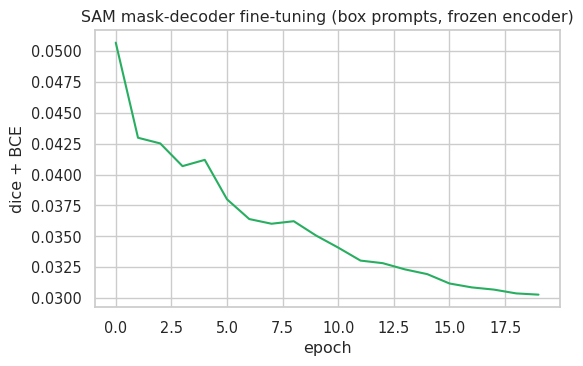

In [7]:
# ── 2. train the mask decoder (encoder + prompt encoder stay frozen) ──
DEC_CKPT = os.path.join(WTS, f'sam_{CFG["sam_variant"]}_rbc_decoder.pt')
for p in sam.image_encoder.parameters():
    p.requires_grad = False
for p in sam.prompt_encoder.parameters():
    p.requires_grad = False
for p in sam.mask_decoder.parameters():
    p.requires_grad = True


def dice_bce(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * target).sum((-2, -1))
    dice = 1 - (2 * inter + eps) / (p.sum((-2, -1)) + target.sum((-2, -1)) + eps)
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none').mean((-2, -1))
    return (dice + bce).mean()


def decode(emb, boxes):
    sparse, dense = sam.prompt_encoder(points=None, boxes=boxes, masks=None)
    low, iou_pred = sam.mask_decoder(
        image_embeddings=emb.expand(len(boxes), -1, -1, -1),
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse, dense_prompt_embeddings=dense,
        multimask_output=False)
    return low, iou_pred


if os.path.exists(DEC_CKPT):
    sam.mask_decoder.load_state_dict(torch.load(DEC_CKPT, map_location=DEV))   # <- rerun-safe
    ft_hist = json.load(open(os.path.join(TAB, 'sam_ft_history.json'))) \
        if os.path.exists(os.path.join(TAB, 'sam_ft_history.json')) else []
    print('loaded fine-tuned decoder ->', DEC_CKPT)
else:
    opt = torch.optim.AdamW(sam.mask_decoder.parameters(), lr=CFG['sam_ft_lr'], weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG['sam_ft_epochs'])
    scaler = make_scaler()
    rng = np.random.default_rng(SEED)
    ft_hist, t0 = [], time.time()
    for ep in range(CFG['sam_ft_epochs']):
        sam.mask_decoder.train()
        tot = n = 0.0
        for k in rng.permutation(len(cache)):
            smear, emb, tm, tb = cache[k]
            emb, tm, tb = emb.to(DEV), tm.to(DEV), tb.to(DEV)
            for s in range(0, len(tb), CFG['sam_box_batch']):
                b = tb[s:s + CFG['sam_box_batch']]
                t = tm[s:s + CFG['sam_box_batch']]
                jit = torch.as_tensor(rng.normal(0, 0.02, b.shape), dtype=torch.float32, device=DEV)
                b = b + jit * (b[:, 2:3] - b[:, 0:1]).clamp(min=1)     # +-2% box jitter
                opt.zero_grad(set_to_none=True)
                with autocast_ctx():
                    low, _ = decode(emb, b)
                    loss = dice_bce(low.float(), t)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                tot += loss.item() * len(b)
                n += len(b)
        sched.step()
        ft_hist.append(tot / max(n, 1))
        print(f'  SAM-ft ep{ep + 1:02d}/{CFG["sam_ft_epochs"]}  dice+bce {ft_hist[-1]:.4f}')
    print(f'decoder fine-tuned in {(time.time() - t0) / 60:.1f} min on {GPU}')
    torch.save(sam.mask_decoder.state_dict(), DEC_CKPT)
    json.dump(ft_hist, open(os.path.join(TAB, 'sam_ft_history.json'), 'w'))

if ft_hist:
    fig, ax = plt.subplots(figsize=(6, 3.6))
    ax.plot(ft_hist, color='#27AE60')
    ax.set_xlabel('epoch')
    ax.set_ylabel('dice + BCE')
    ax.set_title('SAM mask-decoder fine-tuning (box prompts, frozen encoder)')
    savefig(fig, 'seg_sam_ft_loss.png')
    plt.show()

  sam-finetuned: 10/17 smears

  sam-finetuned   (17 held-out GT smears, 466 real cells)
  f1@50                0.6622
  precision@50         0.5051
  recall@50            0.9614
  mean_matched_iou     0.8742
  pixel_iou            0.5014
  mask_ap50            0.6350
  mask_ap50_95         0.4797
  sec_per_smear        1.5528


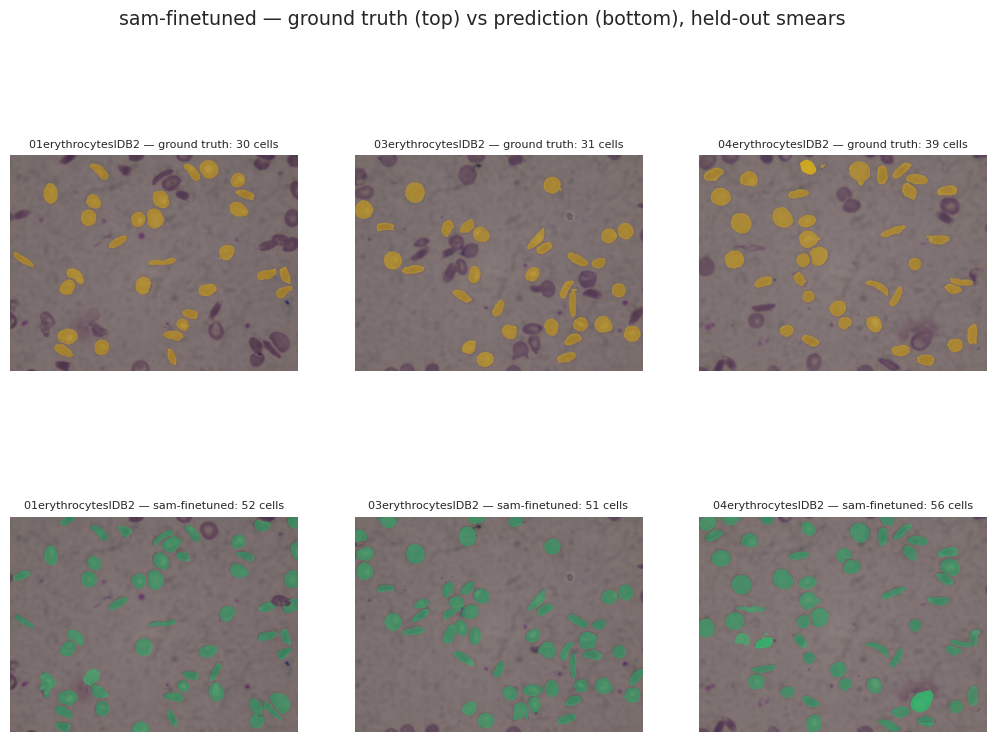


fine-tuning moved F1@50 0.566 -> 0.662 (+0.097)


In [8]:
# ── 3. score the fine-tuned decoder with the SAME automatic protocol ──
sam.eval()
res_sam, per_sam = seg_benchmark(
    sam_predict, 'sam-finetuned',
    notes=f'SAM {CFG["sam_variant"]} decoder fine-tuned {CFG["sam_ft_epochs"]} ep on '
          f'{len(cache)} GT smears, automatic mode',
    extra={'model': f'sam_{CFG["sam_variant"]}', 'weights': DEC_CKPT,
           'points_per_side': CFG['sam_points_bench'], 'train_smears': len(cache),
           'final_loss': ft_hist[-1] if ft_hist else None}, show=3)
save_state(sam_decoder_ckpt=DEC_CKPT, sam_ckpt=SAM_CKPT)

if os.path.exists(os.path.join(BENCH, 'sam-zeroshot.json')):
    zs = json.load(open(os.path.join(BENCH, 'sam-zeroshot.json')))
    print(f"\nfine-tuning moved F1@50 {zs['f1@50']:.3f} -> {res_sam['f1@50']:.3f} "
          f"({res_sam['f1@50'] - zs['f1@50']:+.3f})")
free_gpu('sam')

In [9]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '02_segmentation_sam',
    produced={'sam_backbone': SAM_CKPT,
              'decoder': DEC_CKPT,
              'zeroshot_result': zs_json,
              'finetuned_result': os.path.join(BENCH, 'sam-finetuned.json'),
              'ft_history': os.path.join(TAB, 'sam_ft_history.json'),
              'embedding_cache': EMB_DIR},
    metrics={'zeroshot_f1@50': res_zs['f1@50'],
             'finetuned_f1@50': res_sam['f1@50'],
             'delta_f1@50': res_sam['f1@50'] - res_zs['f1@50'],
             'precision@50': res_sam['precision@50'],
             'recall@50': res_sam['recall@50'],
             'sec_per_smear': res_sam['sec_per_smear'],
             'train_smears': len(cache)},
    notes=f'SAM {CFG["sam_variant"]} mask decoder, {CFG["sam_ft_epochs"]} epochs, '
          'encoder frozen')


  CHECKPOINT  02_segmentation_sam   [ok]   0.9 min
  -> /home/bahajao/runs_two_stage/checkpoints.json   (3 records)
  ok    sam_backbone            357.67 MB  /home/bahajao/runs_two_stage/weights/sam_vit_b.pth
  ok    decoder                  15.53 MB  /home/bahajao/runs_two_stage/weights/sam_vit_b_rbc_decoder.pt
  ok    zeroshot_result           0.00 MB  /home/bahajao/runs_two_stage/seg_bench/sam-zeroshot.json
  ok    finetuned_result          0.00 MB  /home/bahajao/runs_two_stage/seg_bench/sam-finetuned.json
  ok    ft_history                0.00 MB  /home/bahajao/runs_two_stage/tables/sam_ft_history.json
  ok    embedding_cache         122.01 MB  /home/bahajao/runs_two_stage/sam_embed_vit_b
  metric  zeroshot_f1@50       0.565707
  metric  finetuned_f1@50      0.662232
  metric  delta_f1@50          0.096525
  metric  precision@50         0.505073
  metric  recall@50            0.961373
  metric  sec_per_smear        1.552789
  metric  train_smears         61.0

  stages recorded i

{'nb': '02_segmentation_sam',
 'status': 'ok',
 'finished': '2026-08-03 10:23:09',
 'minutes': 0.87,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'vram_gb': 79.3,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49919771',
 'runs_dir': '/home/bahajao/runs_two_stage',
 'metrics': {'zeroshot_f1@50': 0.565707,
  'finetuned_f1@50': 0.662232,
  'delta_f1@50': 0.096525,
  'precision@50': 0.505073,
  'recall@50': 0.961373,
  'sec_per_smear': 1.552789,
  'train_smears': 61.0},
 'artefacts': {'sam_backbone': {'path': '/home/bahajao/runs_two_stage/weights/sam_vit_b.pth',
   'exists': True,
   'kind': 'file',
   'mb': 357.668,
   'modified': '2026-08-02 11:14'},
  'decoder': {'path': '/home/bahajao/runs_two_stage/weights/sam_vit_b_rbc_decoder.pt',
   'exists': True,
   'kind': 'file',
   'mb': 15.526,
   'modified': '2026-08-02 13:01'},
  'zeroshot_result': {'path': '/home/bahajao/runs_two_stage/seg_bench/sam-zeroshot.json',
   'exists': True,
   'kind': 'file',
   'mb': 